Exercise 2.1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

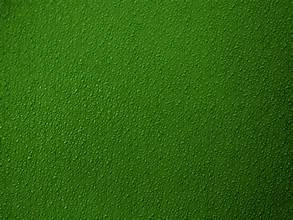

In [ ]:
from PIL import Image

image = Image.open("/green.jpeg")
display(image)

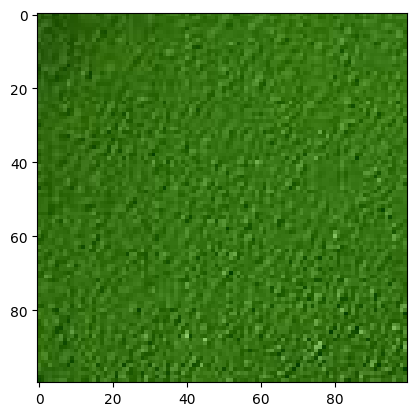

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/green.jpeg")

img_array = np.array(img)

top_left = img_array[:100, :100]

plt.imshow(top_left)
plt.show()

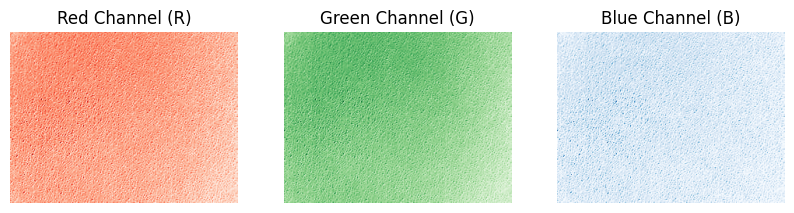

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/green.jpeg")

img_array = np.array(img)

Red = img_array[:, :, 0]
Green = img_array[:, :, 1]
Blue = img_array[:, :, 2]

plt.figure(figsize=(10, 4))

plt.subplot(1,3,1)
plt.imshow(Red, cmap='Reds')
plt.title("Red Channel (R)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(Green, cmap='Greens')
plt.title("Green Channel (G)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(Blue, cmap='Blues')
plt.title("Blue Channel (B)")
plt.axis("off")

plt.show()

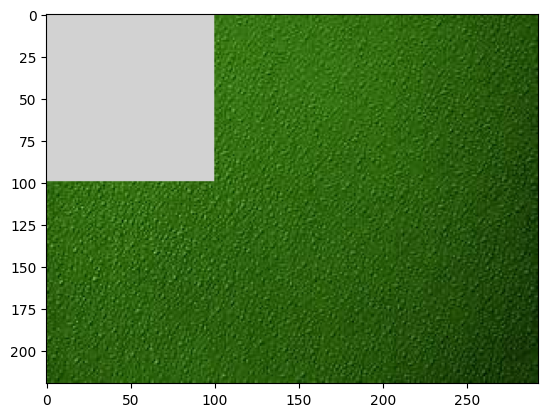

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/green.jpeg")

img_array = np.array(img)

img_array[:100, :100] = 210

plt.imshow(img_array)
plt.show()

Exercise 2.2

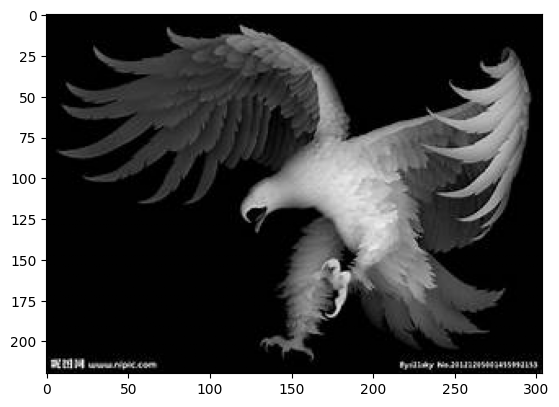

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/grayscale.jpeg").convert("L")

plt.imshow(img, cmap="gray")

plt.show()

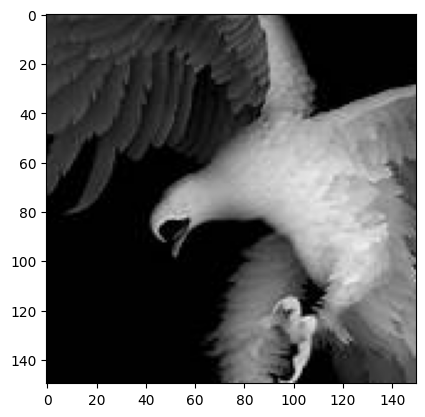

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/grayscale.jpeg")

img_array = np.array(img)

height, width, _ = img_array.shape
center_x = width //2
center_y = height //2
middle = img_array[center_y-75:center_y+75, center_x-75:center_x+75]

plt.imshow(middle)
plt.show()

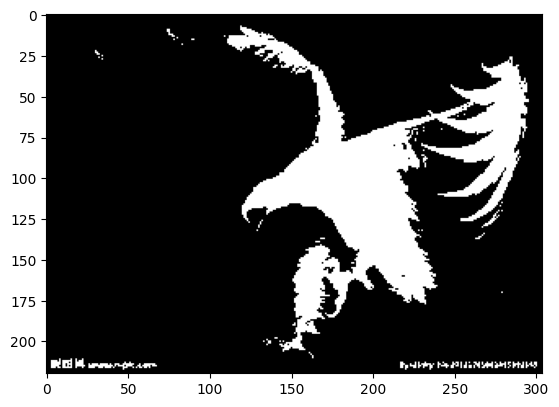

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/grayscale.jpeg").convert("L")

img_array = np.array(img)

binary_img = np.where(img_array < 100, 0, 255)

plt.imshow(binary_img, cmap="gray")
plt.show()

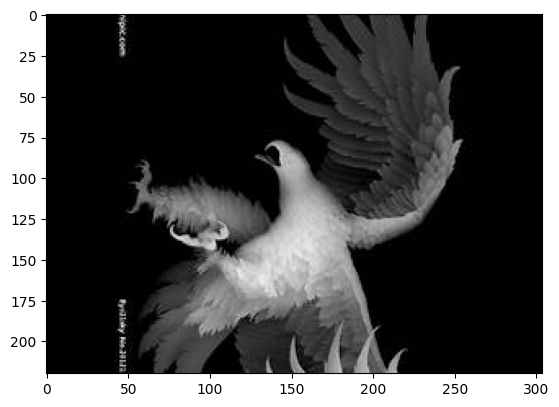

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/grayscale.jpeg")

rotated_img = img.rotate(-90)

plt.imshow(rotated_img)
plt.show()

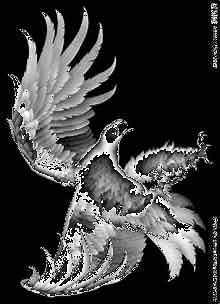

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/grayscale.jpeg").convert("L")

img_array = np.array(img)

rgb_array = np.stack((img_array)*3, axis=-1)

rgb_img = Image.fromarray(rgb_array)

display(rgb_img)

Exercise 3

In [ ]:
from PIL import Image
import numpy as np

img = Image.open("/green.jpeg").convert("L")

data = np.array(img, dtype = np.float64)

X = data

mean = np.mean(X, axis = 0)
std = np.std(X, axis = 0)

X_std = (X - mean) / std

cov_matrix = np.cov(X_std, rowvar = False)

print(cov_matrix.shape)
print(cov_matrix)

(293, 293)
[[ 1.00456621  0.34685535 -0.18944031 ...  0.08491669  0.11776959
   0.10690747]
 [ 0.34685535  1.00456621  0.26886734 ...  0.18546759  0.11029604
   0.08128101]
 [-0.18944031  0.26886734  1.00456621 ...  0.17997001  0.14045161
   0.08711673]
 ...
 [ 0.08491669  0.18546759  0.17997001 ...  1.00456621  0.60846939
   0.30722437]
 [ 0.11776959  0.11029604  0.14045161 ...  0.60846939  1.00456621
   0.88075073]
 [ 0.10690747  0.08128101  0.08711673 ...  0.30722437  0.88075073
   1.00456621]]


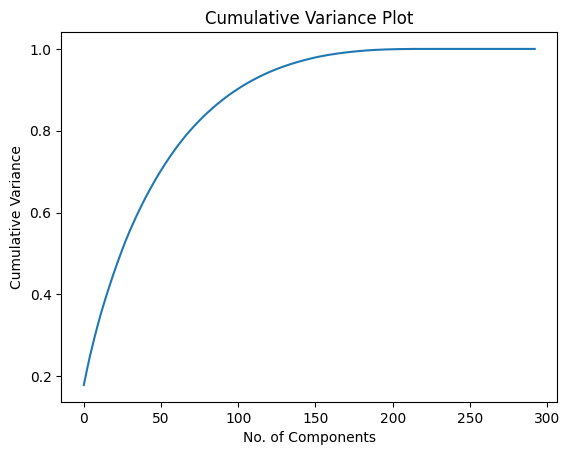

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/green.jpeg").convert("L")

data = np.array(img, dtype = np.float64)

X = data

mean = np.mean(X, axis = 0)
std = np.std(X, axis = 0)
cov_matrix = np.cov(X, rowvar = False)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

c_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)

plt.plot(c_variance)
plt.title("Cumulative Variance Plot")
plt.xlabel("No. of Components")
plt.ylabel("Cumulative Variance")
plt.show()


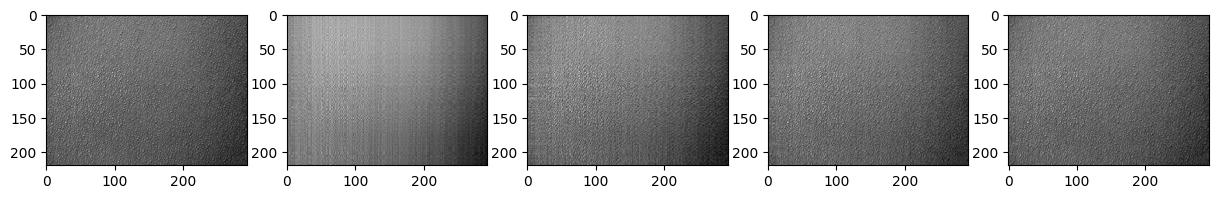

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/green.jpeg").convert("L")
data = np.array(img, dtype=np.float64)
X = data

mean = np.mean(X, axis=0)
X_centered = X - mean

cov_matrix = np.cov(X_centered, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

c_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)

def reconstruct_image(X_centered, mean, eigenvectors, k):
    top_k_eigenvectors = eigenvectors[:, :k]
    X_low_dim = np.dot(X_centered, top_k_eigenvectors)
    X_reconstructed = np.dot(X_low_dim, top_k_eigenvectors.T) + mean
    return X_reconstructed

k_values = [5, 20, 50, 100]
reconstructed_images = []

for k in k_values:
    rec = reconstruct_image(X_centered, mean, eigenvectors, k)
    reconstructed_images.append(rec)

plt.figure(figsize=(15,4))
plt.subplot(1, 5, 1)
plt.imshow(X, cmap='gray')

for i, rec in enumerate(reconstructed_images):
    plt.subplot(1, 5, i+2)
    plt.imshow(rec, cmap='gray')

plt.show()